In [1]:
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord, Angle
from astropy.table import Table, vstack
from astropy.time import Time
from astropy.io import fits
from regions import CircleSkyRegion
import matplotlib.pyplot as plt
import multiprocessing as mp
import pandas as pd
import os
import glob
from scipy.stats import halfnorm
from scipy.integrate import quad
from scipy.optimize import curve_fit
from collections import OrderedDict

# %matplotlib inline
from pathlib import Path
from IPython.display import display
from gammapy.data import FixedPointingInfo, Observation, observatory_locations, DataStore, ObservationTable, EventList, PointingInfo, GTI
from gammapy.analysis import Analysis, AnalysisConfig
from gammapy.datasets import Datasets, FluxPointsDataset, SpectrumDataset, SpectrumDatasetOnOff, MapDataset, MapDatasetEventSampler
from gammapy.irf import load_irf_dict_from_file, EDispKernelMap, EffectiveAreaTable2D, Background3D, BackgroundIRF, FoVAlignment
from gammapy.estimators import ASmoothMapEstimator, TSMapEstimator, FluxPointsEstimator
from gammapy.makers import MapDatasetMaker, SafeMaskMaker, ReflectedRegionsBackgroundMaker, SpectrumDatasetMaker
from gammapy.makers.utils import make_theta_squared_table
from gammapy.estimators.utils import find_peaks, find_peaks_in_flux_map, resample_energy_edges
from gammapy.maps import MapAxis, WcsGeom, RegionGeom, Map
from gammapy.estimators import ExcessMapEstimator, LightCurveEstimator
from gammapy.modeling import Fit
from gammapy.modeling.models import (
    PointSpatialModel,
    FoVBackgroundModel,
    GaussianSpatialModel,
    LogParabolaSpectralModel,
    LogParabolaNormSpectralModel,
    Models,
    ExpCutoffPowerLawSpectralModel,
    PowerLawSpectralModel,
    SkyModel,
    TemplateSpectralModel,
    ExpCutoffPowerLawNormSpectralModel,
    CompoundSpectralModel,
    SmoothBrokenPowerLawSpectralModel,
)
from gammapy.visualization import plot_distribution
from regions import CircleSkyRegion
from gammapy.modeling import Parameter, Parameters
from gammapy.modeling.models import SpectralModel, PowerLawSpectralModel 
from scipy.optimize import curve_fit

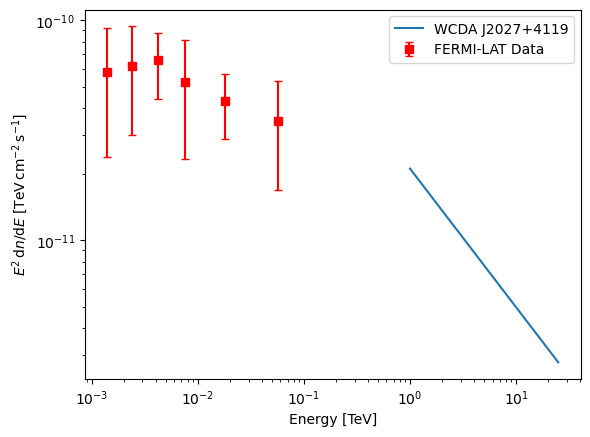

In [2]:
# LHAASO J2027+4119
energy_bounds_WCDA = [1, 25] * u.TeV
model_WCDA = PowerLawSpectralModel(
    index=2.63,
    amplitude="1.27e-9 TeV-1 m-2 s-1",
    reference=7 * u.TeV,
)
ra = 307.43 * u.deg
dec = 41.05 * u.deg

c = SkyCoord(ra=ra, dec=dec, frame='icrs')

lon = c.galactic.l.deg * u.deg
lat = c.galactic.b.deg * u.deg
spatial_WCDA = GaussianSpatialModel(lon_0=lon, lat_0=lat, sigma="2.17 deg")

energy_WCDA = np.logspace(np.log10(1), np.log10(25), 200) * u.TeV


dnde_WCDA = model_WCDA(energy_WCDA)
e2dnde_WCDA = (energy_WCDA**2 * dnde_WCDA).to("TeV cm-2 s-1")

plt.loglog(energy_WCDA, e2dnde_WCDA, label="WCDA J2027+4119")


#energy_fermilat = np.array([240, 420, 750, 1400, 2400, 4200, 7600, 18000, 57000]) * u.MeV
energy_fermilat = np.array([1400, 2400, 4200, 7600, 18000, 57000]) * u.MeV
energy_fermilat = energy_fermilat.to(u.TeV)

#e2dnde_fermilat = np.array([5.6e-5, 9.9e-5, 8.6e-5, 5.8e-5, 6.2e-5, 6.6e-5, 5.25e-5, 4.3e-5, 3.5e-5]) * u.MeV / (u.cm**2 * u.s)
e2dnde_fermilat = np.array([5.8e-5, 6.2e-5, 6.6e-5, 5.25e-5, 4.3e-5, 3.5e-5]) * u.MeV / (u.cm**2 * u.s)
e2dnde_fermilat = e2dnde_fermilat.to(u.TeV / (u.cm**2 * u.s))
#err_fermilat = np.array([0, 0, 0, 3.4e-5, 3.2e-5,2.2e-5, 2.9e-5, 1.4e-5, 1.8e-5]) * u.MeV / (u.cm**2 * u.s)
err_fermilat = np.array([3.4e-5, 3.2e-5,2.2e-5, 2.9e-5, 1.4e-5, 1.8e-5]) * u.MeV / (u.cm**2 * u.s)

err_fermilat = err_fermilat.to(u.TeV / (u.cm**2 * u.s))




plt.grid(which="both")
plt.errorbar(energy_fermilat, e2dnde_fermilat, yerr=err_fermilat, fmt='s', color='red', ecolor='red', capsize=3, linestyle='none', label='FERMI-LAT Data')
plt.xlabel("Energy [TeV]")
plt.ylabel(r"$E^2\,\mathrm{d}n/\mathrm{d}E\;[\mathrm{TeV\,cm^{-2}\,s^{-1}}]$")
plt.grid(which="both")
plt.legend()
plt.show()

[2.12036959e-11 1.37013282e-11 1.06126826e-11 8.85347513e-12
 7.69237528e-12 6.85766520e-12 6.22300000e-12 5.72090682e-12
 5.31176417e-12 4.97063148e-12 3.21190483e-12] TeV / (s cm2)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] TeV / (s cm2)


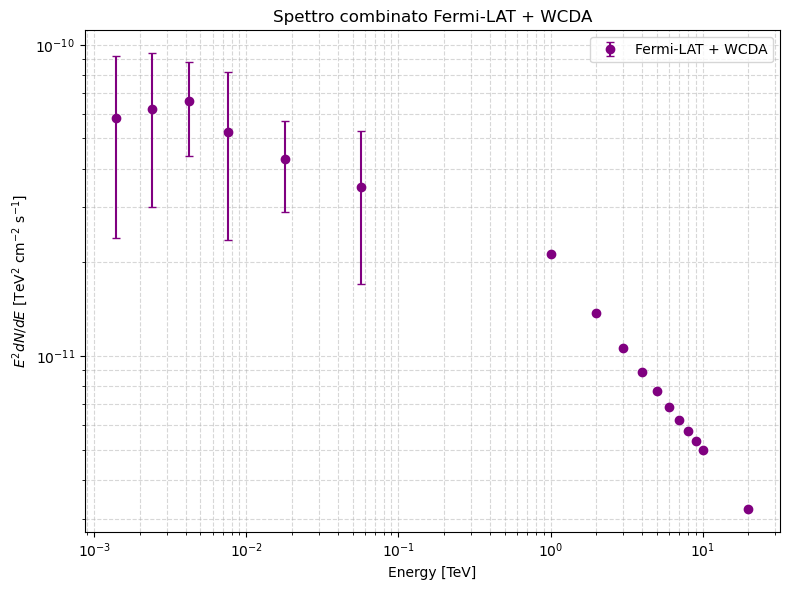

In [15]:
# --- Punti WCDA ---
en_points = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20]) * u.TeV
dnde_WCDA_points  = model_WCDA(en_points)
e2dnde_WCDA_points = (en_points**2 * dnde_WCDA_points).to(u.TeV/ (u.cm**2 * u.s))

print(e2dnde_WCDA_points)

# Errori WCDA (tutti zero, stessa unità)
err_WCDA = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])* u.TeV/ (u.cm**2 * u.s)
print(err_WCDA)

# --- Concatenazione e ordinamento ---
energy_combined = np.concatenate([energy_fermilat, en_points])
e2dnde_combined = np.concatenate([e2dnde_fermilat, e2dnde_WCDA_points])
err_combined = np.concatenate([err_fermilat, err_WCDA])

sort_idx = np.argsort(energy_combined)
energy_combined = energy_combined[sort_idx]
e2dnde_combined = e2dnde_combined[sort_idx]
err_combined = err_combined[sort_idx]

# --- Plot log-log con barre di errore ---
plt.figure(figsize=(8,6))
plt.errorbar(
    energy_combined, e2dnde_combined,
    yerr=err_combined,
    fmt='o', markersize=6, capsize=3, color='purple', label='Fermi-LAT + WCDA'
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [TeV]')
plt.ylabel(r'$E^2 dN/dE$ [TeV$^2$ cm$^{-2}$ s$^{-1}$]')
plt.title('Spettro combinato Fermi-LAT + WCDA')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


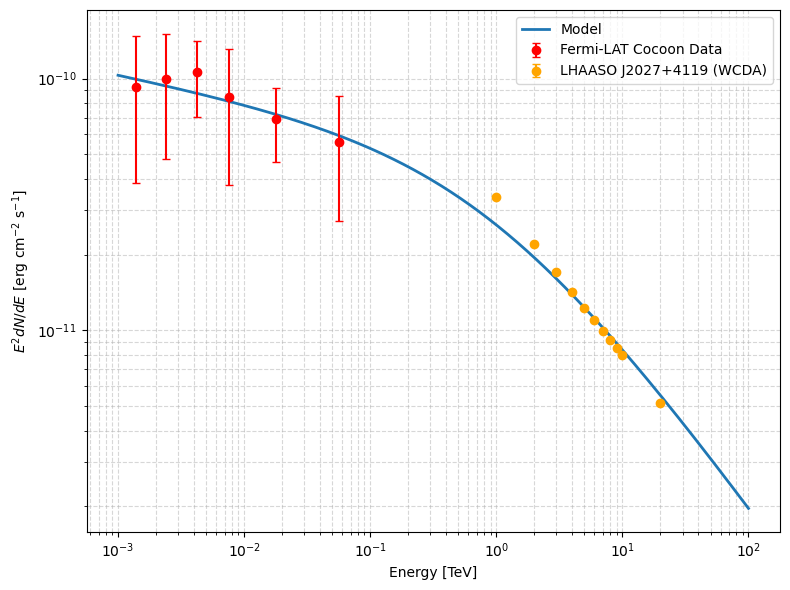

In [23]:
# Modello
model = SmoothBrokenPowerLawSpectralModel(
    index1=2.1,
    index2=2.7,
    amplitude="5.5e-13 TeV-1 cm-2 s-1",
    ebreak="1 TeV",
    reference="7 TeV",
    beta=1,
)

# Energia per il modello
energy = np.logspace(np.log10(1e-3), np.log10(100), 200) * u.TeV
dnde = model(energy)
e2dnde_model = (energy**2 * dnde).to("TeV cm-2 s-1")
e2dnde_model = e2dnde_model.to("erg cm-2 s-1")
# Conversione punti sperimentali

en_points_TeV = en_points.to(u.TeV).value

# Plot unico
plt.figure(figsize=(8, 6))

# Modello
plt.plot(
    energy.to(u.TeV).value,
    e2dnde_model.value,
    label="Model",
    lw=2,
)

e2dnde_combined = e2dnde_combined.to("erg cm-2 s-1")
err_combined = err_combined.to("erg cm-2 s-1")
plt.errorbar(
    energy_combined[:6], e2dnde_combined[:6],
    yerr=err_combined[:6],
    fmt='o', markersize=6, capsize=3, color='red', label='Fermi-LAT Cocoon Data'
)

# Secondo gruppo: punti rimanenti
plt.errorbar(
    energy_combined[6:], e2dnde_combined[6:],
    yerr=err_combined[6:],
    fmt='o', markersize=6, capsize=3, color='orange', label='LHAASO J2027+4119 (WCDA)'
)
# Assi e stile
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energy [TeV]")
plt.ylabel(r"$E^2 dN/dE$ [erg cm$^{-2}$ s$^{-1}$]")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
import os

# Cartella di destinazione
folder = "/Users/camillaquartiroli/Desktop/GAMMAPY/Notebook/Cygnus/plot_modelli"

# Crea la cartella se non esiste
os.makedirs(folder, exist_ok=True)

# Salvataggio del file
plt.savefig(os.path.join(folder, "LHAASOJ2027+4119.png"), dpi=300)
plt.show()

In [92]:
ra = 306.9 * u.deg
dec = 41.33 * u.deg

c = SkyCoord(ra=ra, dec=dec, frame='icrs')

lon = c.galactic.l.deg * u.deg
lat = c.galactic.b.deg * u.deg

print(lon, lat)


gauss = GaussianSpatialModel(lon_0=lon, lat_0=lat, sigma="2.28 deg")
OB2model = SkyModel(spatial_model=gauss,  spectral_model=model, name="Fermi Cocooon + LHAASO J2027+4119 ")
models = Models([OB2model])

print(models.to_yaml())
models.write("CygnusBubble_model.yaml", overwrite=True)

79.61227004789605 deg 1.6544814108964416 deg
components:
-   name: 'Fermi Cocooon + LHAASO J2027+4119 '
    type: SkyModel
    spectral:
        type: SmoothBrokenPowerLawSpectralModel
        parameters:
        -   name: index1
            value: 2.1
        -   name: index2
            value: 2.7
        -   name: amplitude
            value: 5.5e-13
            unit: TeV-1 s-1 cm-2
        -   name: ebreak
            value: 1.0
            unit: TeV
        -   name: reference
            value: 7.0
            unit: TeV
        -   name: beta
            value: 1.0
    spatial:
        type: GaussianSpatialModel
        frame: icrs
        parameters:
        -   name: lon_0
            value: 79.61227004789605
            unit: deg
        -   name: lat_0
            value: 1.6544814108964416
            unit: deg
        -   name: sigma
            value: 2.28
            unit: deg
        -   name: e
            value: 0.0
        -   name: phi
            value: 0.0
         

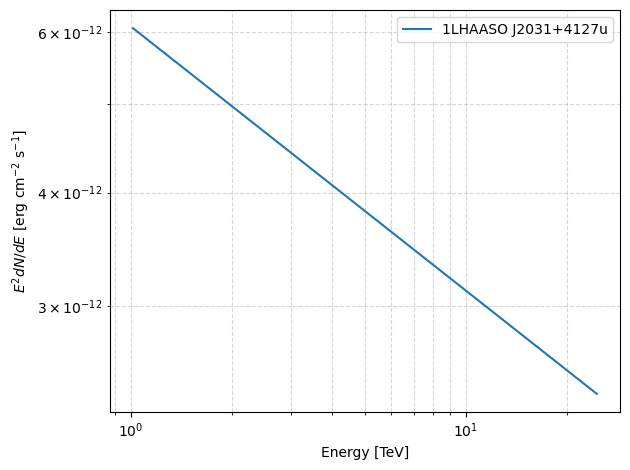

In [24]:
'''
# Modello
model = SmoothBrokenPowerLawSpectralModel(
    index1=2.1,
    index2=2.7,
    amplitude="5.5e-13 TeV-1 cm-2 s-1",
    ebreak="1 TeV",
    reference="7 TeV",
    beta=1,
)

# Energia per il modello
energy = np.logspace(np.log10(1e-3), np.log10(100), 200) * u.TeV
dnde = model(energy)
e2dnde_model = (energy**2 * dnde).to("TeV cm-2 s-1")
e2dnde_model = e2dnde_model.to("erg cm-2 s-1")
# Conversione punti sperimentali

en_points_TeV = en_points.to(u.TeV).value

# Plot unico
plt.figure(figsize=(8, 6))

# Modello
plt.plot(
    energy.to(u.TeV).value,
    e2dnde_model.value,
    label="Model",
    lw=2,
)

e2dnde_combined = e2dnde_combined.to("erg cm-2 s-1")
err_combined = err_combined.to("erg cm-2 s-1")
plt.errorbar(
    energy_combined[:6], e2dnde_combined[:6],
    yerr=err_combined[:6],
    fmt='o', markersize=6, capsize=3, color='red', label='Fermi-LAT Cocoon Data'
)

# Secondo gruppo: punti rimanenti
plt.errorbar(
    energy_combined[6:], e2dnde_combined[6:],
    yerr=err_combined[6:],
    fmt='o', markersize=6, capsize=3, color='orange', label='LHAASO J2027+4119 (WCDA)'
)
'''
energy_bounds_LHHASO = [1, 25] * u.TeV
model_LHAASO = PowerLawSpectralModel(
    index=2.29,
    amplitude="3.07e-13 TeV-1 cm-2 s-1",
    reference=3 * u.TeV,
)
model_LHAASO.plot(energy_bounds_LHHASO,sed_type='e2dnde', label = "1LHAASO J2031+4127u")
# Assi e stile
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energy [TeV]")
plt.ylabel(r"$E^2 dN/dE$ [erg cm$^{-2}$ s$^{-1}$]")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
import os

# Cartella di destinazione
folder = "/Users/camillaquartiroli/Desktop/GAMMAPY/Notebook/Cygnus/plot_modelli"

# Crea la cartella se non esiste
os.makedirs(folder, exist_ok=True)

# Salvataggio del file
plt.savefig(os.path.join(folder, "LHAASOJ2027+4119.png"), dpi=300)
plt.show()